In [2]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt

mnist = fetch_openml(
    "mnist_784",
    as_frame=False
)

X, y = mnist["data"], mnist["target"]

In [3]:
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


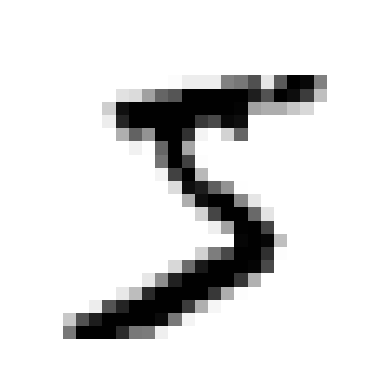

In [4]:
some_digit = X[0]

some_digit_image = some_digit.reshape(
    28, 28
)

plt.imshow(
    some_digit_image,
    cmap="binary"
)

plt.axis("off")
plt.show()

In [5]:
print(y[0])

5


In [6]:
y = y.astype(np.uint8)

 The dataset contains 70,000 images, as shown by the first number in X.shape, which is (70000, 784).
- Each image contains 784 features, representing its 784 individual pixels. Each image has 28 rows and 28 columns, so 28 x 28 = 784.
- There are 10 classes, representing the handwritten digits from 0 to 9.
- Each feature represents the pixel intensity of one pixel in the handwritten digit image. The 784 pixel values describe the image when it is converted into a numerical representation.
- The target variable is y, which contains the correct digit label for each image. In the screenshot, y[0] is 5, meaning the first image is labelled as the digit 5.
- Visual inspection helps us understand the data, confirm that the images represent handwritten digits, and check whether the labels correspond to the images. It can also help reveal unexpected data issues before training the model.

In [7]:
X_train = X[:60000]
X_test = X[60000:]

y_train = y[:60000]
y_test = y[60000:]

In [8]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

In [9]:

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(60000, 784)
(10000, 784)
(60000,)
(10000,)


- The positive class is digit 5. Any image representing the digit 5 is classified as positive (True).
- The negative class consists of all digits other than 5, namely 0, 1, 2, 3, 4, 6, 7, 8 and 9. These images are classified as negative (False).
- It is called binary classification because the model predicts between only two possible classes: digit 5 (positive) and not digit 5 (negative).

In [10]:

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)

sgd_clf.fit(X_train, y_train_5)


,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [11]:

sgd_clf.predict([some_digit])


array([ True])

In [12]:

print("Actual digit:", y[0])
print("Predicted result:", sgd_clf.predict([some_digit]))


Actual digit: 5
Predicted result: [ True]


In [13]:

for i in range(10):
    prediction = sgd_clf.predict([X[i]])[0]
    actual_digit = y[i]

    print(
        "Image:", i,
        "| Actual digit:", actual_digit,
        "| Actual is 5:", actual_digit == 5,
        "| Prediction:", prediction
    )


Image: 0 | Actual digit: 5 | Actual is 5: True | Prediction: True
Image: 1 | Actual digit: 0 | Actual is 5: False | Prediction: False
Image: 2 | Actual digit: 4 | Actual is 5: False | Prediction: False
Image: 3 | Actual digit: 1 | Actual is 5: False | Prediction: False
Image: 4 | Actual digit: 9 | Actual is 5: False | Prediction: False
Image: 5 | Actual digit: 2 | Actual is 5: False | Prediction: False
Image: 6 | Actual digit: 1 | Actual is 5: False | Prediction: False
Image: 7 | Actual digit: 3 | Actual is 5: False | Prediction: False
Image: 8 | Actual digit: 1 | Actual is 5: False | Prediction: False
Image: 9 | Actual digit: 4 | Actual is 5: False | Prediction: False


- The classifier correctly identified the digit 5 in the first image tested. However, testing only a few images is insufficient to conclude that it correctly identifies all images of digit 5.
- In the first ten images tested, the classifier did not classify any non-5 digit as a 5. All nine non-5 images were correctly predicted as False.
- Checking only a few predictions does not provide a reliable assessment of the classifier's overall performance. The model may perform correctly on the selected images but misclassify other images. Therefore, evaluation metrics and cross-validation are needed to estimate its performance more reliably.

In [14]:

from sklearn.model_selection import cross_val_score

cross_val_score(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    scoring="accuracy"
)


array([0.95035, 0.96035, 0.9604 ])

In [15]:

scores = cross_val_score(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    scoring="accuracy"
)

print("Mean accuracy:", scores.mean())
print("Mean accuracy (%):", scores.mean() * 100)


Mean accuracy: 0.9570333333333334
Mean accuracy (%): 95.70333333333335


- Mean accuracy of 95%
- Yes, the mean accuracy of approximately 95.70% is high. This means the classifier correctly classified about 95.70% of the examples in the validation folds.
- No. Accuracy can be misleading when one class is much more common than the other. A classifier could predict that every image is not a 5 and still achieve high accuracy because most MNIST images are not 5s. However, it would fail to identify any actual 5s.
- When the positive class is rare, a classifier can achieve high accuracy by mostly or always predicting the negative class. This can make the model appear effective even when it fails to identify most positive examples.

In [16]:

from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3
)


In [17]:

from sklearn.metrics import confusion_matrix

conf_mx = confusion_matrix(
    y_train_5,
    y_train_pred
)

print(conf_mx)


[[53892   687]
 [ 1891  3530]]


- True positives (TP): 3,530: These are images that actually represent digit 5 and were correctly predicted as 5 by the classifier.
- True negatives (TN): 53,892: These are images that do not represent digit 5 and were correctly predicted as not 5.
- False positives (FP): 687: These are images that do not represent digit 5 but were incorrectly classified as 5 by the model.
- False negatives (FN): 1,891: These are images that actually represent digit 5 but were incorrectly classified as not 5.
The classifier correctly identified 53,892 non-5 images and 3,530 images of digit 5. However, it missed 1,891 actual 5s and incorrectly labelled 687 non-5 images as 5.

In [18]:

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(
    y_train_5,
    y_train_pred
)

recall = recall_score(
    y_train_5,
    y_train_pred
)

f1 = f1_score(
    y_train_5,
    y_train_pred
)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Precision: 0.8370879772350012
Recall: 0.6511713705958311
F1-score: 0.7325171197343847


- Precision measures the proportion of images predicted as digit 5 that are actually digit 5. A high precision means that the classifier produces relatively few false positives.
- Recall measures the proportion of actual digit 5 images that the classifier correctly identifies. A high recall means that the classifier misses relatively few actual 5s.
- The F1-score is the harmonic mean of precision and recall. It provides a single measure that considers both metrics, making it useful when we want to balance false positives and false negatives.
- Precision would be more important because it measures how often a positive prediction is correct. Higher precision helps reduce false positive predictions.
- Recall would be more important because it measures how many actual positive cases are successfully identified. Higher recall helps reduce false negatives.
Real-world examples
- High precision: Email spam filtering. If a legitimate email is incorrectly marked as spam, an important message may be missed. High precision helps ensure that emails marked as spam really are spam.
- High recall: Cybersecurity threat detection. Missing a genuine security threat can allow an attack to continue. High recall helps identify as many genuine threats as possible, although this may also produce more false alarms.

In [19]:

from sklearn.model_selection import cross_val_predict

y_scores = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    method="decision_function"
)


In [20]:

print(y_scores[:10])


[  1200.93051237 -26883.79202424 -33072.03475406 -15919.5480689
 -20003.53970191 -16652.87731528 -14276.86944263 -23328.13728948
  -5172.79611432 -13873.5025381 ]


In [21]:

from sklearn.metrics import precision_score, recall_score

thresholds_to_test = [-10000, 0, 10000, 20000]

for threshold in thresholds_to_test:
    y_threshold_pred = (y_scores >= threshold)

    precision = precision_score(
        y_train_5,
        y_threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_train_5,
        y_threshold_pred
    )

    print(
        "Threshold:", threshold,
        "| Precision:", round(precision, 4),
        "| Recall:", round(recall, 4)
    )


Threshold: -10000 | Precision: 0.3528 | Recall: 0.9445
Threshold: 0 | Precision: 0.8371 | Recall: 0.6512
Threshold: 10000 | Precision: 0.9467 | Recall: 0.2193
Threshold: 20000 | Precision: 0.9627 | Recall: 0.0428


- Precision generally increases because the classifier becomes more selective when predicting the positive class, reducing the proportion of false positives among positive predictions.
- Recall generally decreases because more actual positive examples fall below the threshold and are classified as negative.
- The threshold determines the minimum decision score required to classify an image as a 5. Changing it changes the number of positive predictions, affecting both false positives and false negatives.
- No. The appropriate threshold depends on the application's requirements and the relative costs of false positives and false negatives.

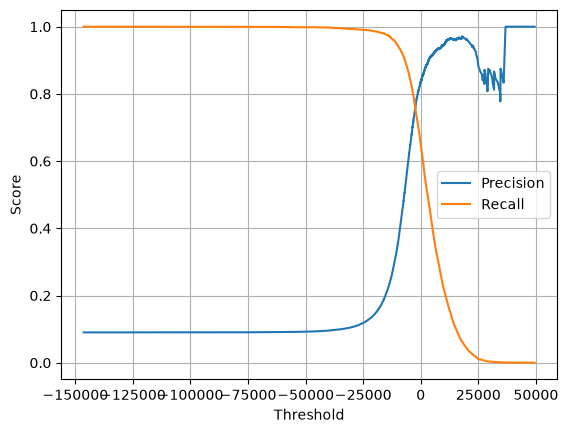

In [22]:

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(
    y_train_5,
    y_scores
)

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid()
plt.legend()
plt.show()


- Precision generally increases because the classifier becomes more selective when predicting the positive class, reducing the proportion of false positives among positive predictions.
- Recall generally decreases because more actual positive examples receive scores below the threshold and are classified as negative.
- A company should choose a threshold based on its application requirements and the relative costs of false positives and false negatives. For example, a cybersecurity team may prioritize identifying as many genuine threats as possible, while also considering the workload caused by false alarms.
- The default threshold may not provide the precision-recall balance required by a particular application. Adjusting the threshold allows the company to prioritize the metric that matters most for its objectives.

In [23]:

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_train_5,
    y_scores
)


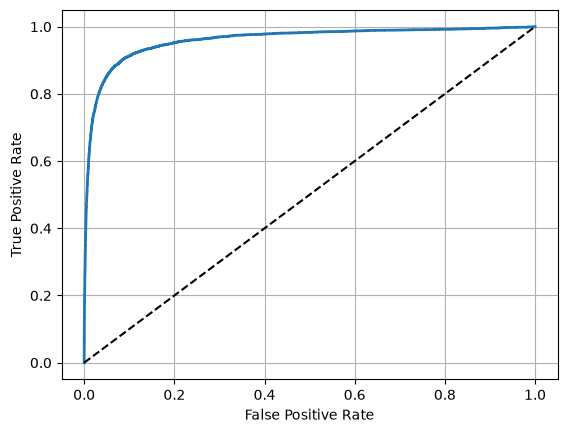

In [24]:

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.show()


In [25]:

from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_train_5,
    y_scores
)

print("ROC-AUC:", roc_auc)



ROC-AUC: 0.9604938554008616


task 9.1
- The ROC curve illustrates the relationship between the true positive rate and the false positive rate at different classification thresholds. It helps evaluate how well a classifier distinguishes between positive and negative classes.
- The x-axis represents the false positive rate (FPR), which measures the proportion of actual negative examples incorrectly classified as positive and the y-axis represents the true positive rate (TPR), also known as recall, which measures the proportion of actual positive examples correctly identified.
- A ROC-AUC value close to 1 indicates that the classifier has excellent ability to distinguish between positive and negative classes.
- A ROC-AUC value close to 0.5 indicates that the classifier's ability to distinguish between positive and negative examples is approximately equivalent to random ranking.

In [26]:

sgd_clf.fit(
    X_train,
    y_train
)


,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [27]:

sgd_clf.fit(
    X_train,
    y_train
)
                                                                                                                                                                                                                                                                                                                 

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [28]:

sgd_clf.predict([some_digit])


array([3], dtype=uint8)

In [29]:


some_digit_scores = sgd_clf.decision_function(
    [some_digit]
)

print(some_digit_scores)



[[-31893.03095419 -19047.55566534  -9530.63950739   1823.73154031
  -22320.14822878  -1385.80478895 -26188.91070951 -16147.51323997
   -4604.35491274 -12050.767298  ]]


In [30]:

print(sgd_clf.classes_)


[0 1 2 3 4 5 6 7 8 9]


Task 10.1
- The classifier predicts 10 classes, representing the digits 0 through 9.
- The decision score indicates how strongly the classifier favors a particular class for a given image. A higher score indicates stronger support for that class relative to the other classes.
- Class 3 has the highest decision score, approximately 1,823.73. Therefore, the model predicts that the image represents digit 3.
- No, not manually. Scikit-learn's SGDClassifier handles multiclass classification automatically.

In [31]:

from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(
    sgd_clf,
    X_train,
    y_train,
    cv=3
)


In [32]:

from sklearn.metrics import confusion_matrix

conf_mx = confusion_matrix(
    y_train,
    y_train_pred
)

print(conf_mx)


[[5565    0   69   16   21   73   50   13   83   33]
 [   3 6399   95   20   15   47   16   17  110   20]
 [  33   56 5202   93   69   42  158   74  213   18]
 [  12   32  218 4953   24  446   33   66  212  135]
 [  11   26   47    5 5285   25   70   36   83  254]
 [  40   23   58  149   85 4631  166   23  156   90]
 [  24   11   66    6   26  115 5627    4   37    2]
 [  22   24  103   33  124   41   10 5221   72  615]
 [  26  101  156  121   48  461   76   47 4647  168]
 [  23   14   55   72  503  125    5  447  123 4582]]


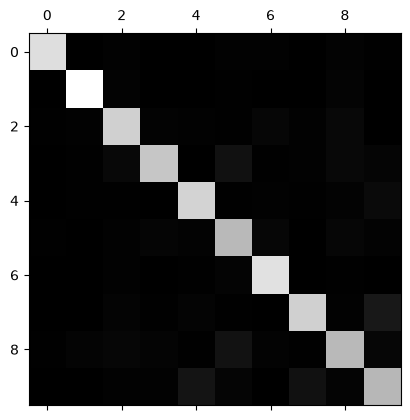

In [33]:

import matplotlib.pyplot as plt

plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()


Task 11.1
- The digits that appear to be confused most often are 7, 9, 4, 5, 3
- Digits 1, 0 and 6 appear relatively easy for the classifier to recognize, as shown by their strong diagonal values in the confusion matrix.
- A confusion matrix provides detailed information about correct predictions and misclassifications for each class.

In [34]:

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)

y_multilabel = np.c_[
    y_train_large,
    y_train_odd
]


In [35]:

from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier",list,"[array([False, True]), array([False, True])]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [36]:

knn_clf.predict([some_digit])


array([[False,  True]])

Task 12.1
- In ordinary multiclass classification, each observation belongs to one class among several possible classes. In multilabel classification, an observation can have multiple labels at the same time.
- According to the exercise and lab, observations receive 2 labels; Whether the digit is greater than or equal to 7 or whether the digit is odd.
- The prediction represents the two properties of the image. For your some_digit, the prediction [False, True] means that the digit is not greater than or equal to 7, but it is odd.

In [37]:
y_train_knn_pred = cross_val_predict(
    knn_clf,
    X_train,
    y_multilabel,
    cv=3
)

In [38]:
from sklearn.metrics import f1_score

f1_score(
    y_multilabel,
    y_train_knn_pred,
    average="macro"
)

0.9764102655606048

Task 13.1
- A multilabel classifier can assign multiple labels to the same observation, so its performance must be evaluated across several labels rather than a single positive/negative outcome. Each label can have its own precision and recall, and an averaging method such as macro averaging can be used to summarize performance across the labels.
- Different metrics measure different aspects of model performance. The appropriate metric should reflect the objectives of the classification problem and the relative importance of different types of errors. For multilabel classification, the metric should account for performance across the multiple labels.